In [6]:
from data_loaders import  CUB_dataset

import os
import torch
import pickle
import numpy as np
import torchvision.transforms as transforms
from torchvision.transforms import RandomResizedCrop
from torchvision.transforms.functional import resized_crop
import pandas as pd
from PIL import Image
from torch.utils.data import BatchSampler
from torch.utils.data import Dataset, DataLoader

from collections import defaultdict as ddict

In [ ]:
class transform_dataset(CUB_dataset):
    def __init__(self,mode:str, config_dict: dict,transform=None,crop_size:int =299):
        """
        Coustom dataset that instead of using a transform function can perform a coustom transformation that also crops out non visible concepts.
        Args:
        config_dict: dict, dictionary containing all the necessary information for the dataset
        transform: "RandomResized" or "CenterCrop" or "Resize"
        """

        self.crop_size = crop_size

        #Use the coustome transform of this class
        super().__init__(mode,config_dict,transform=None)

        self.transform = transform



        #Read the file with the names of bird location attributes
        self.part_names = []
        with open(os.path.join(config_dict['CUB_dir'],"parts","parts.txt")) as f:
            for line in f:
                self.part_names.append(line.strip().split(" ")[1:]) #remove the first element which is the index of the attribute


        self.part_locations=pd.read_csv(os.path.join(config_dict['CUB_dir'],"parts","part_locs.txt"), sep=" ", header=None)
        self.part_locations.columns = ["id","part","x","y","visible"]


        
        self.part_names_single = ['back', 'beak', 'belly', 'breast', 'crown', 'forehead', 'eye', 'leg', 'wing', 'nape', 'tail', 'throat'] #List of all path without left and right

        #Load concept labels names
        self.consept_labels_names = pd.read_csv(os.path.join(config_dict['CUB_dir'],"atributes.txt"), sep=" ", header=None)[1].values

        #Load class labels names
        self.class_labels_names = pd.read_csv(os.path.join(config_dict['CUB_dir'],"classes.txt"), sep=" ", header=None)[1].values

        #If a filter was applied load the filter names.
        if self.majority_voting:
            self.consept_labels_names = self.consept_labels_names[self.concept_mask]

    def concept_transform(self,img,concepts,coordinates,methode:str):
        """
        A methode that crop an image like random rezised crop or center crop but also tell what concept are visible after the crop
        """
        
        if methode == "RandomResize":

            crop_method = transforms.RandomResizedCrop(self.crop_size)

            # Get the parameters of the crop
            top, left, height, width = crop_method.get_params(img, crop_method.scale, crop_method.ratio)


        elif methode == "CenterCrop":

            crop_method = transforms.CenterCrop(self.crop_size)

            # Get the parameters of the crop
            left = (img.size[0] - self.crop_size) // 2
            top = (img.size[1] - self.crop_size) // 2
            
            height = self.crop_size
            width = self.crop_size
        
        elif methode == "Resize":
            
            #Don't crop the image
            top = 0
            left = 0
            width = img.size[0]
            height = img.size[1]


        else:
            raise ValueError(f"Methode {methode} not recognized")

        #Apply the crop
        img = resized_crop(img, top, left, height, width, (self.crop_size,self.crop_size))

        for n in range(len(concepts)):

            #Get the coordinates of the concept
            coordinate = coordinates[n]

            if len(coordinate)==0:
                # Don't do anything if the concept is not visible or has no coordinates
                continue

            elif len(coordinate)==1:
                x,y = coordinate[0]
                if left <= x <= left+width and top <= y <= top+height:
                    # Rescale the coordinates to the new image size
                    coordinates[n] = [((x-left)/(width/self.crop_size),(y-top)/(height/self.crop_size))]
                else:
                    # Remove the coordinate if it is not in new crop
                    coordinates[n] = []
                    concepts[n] = 0 #Set the concept to 0 if it is not visible
            
            
            elif len(coordinate)==2:
                x1,y1 = coordinate[0]
                x2,y2 = coordinate[1]

                new_coordinate = []

                

                if left <= x1 <= left+width and top <= y1 <= top+height:
                    # Rescale the left part coordinates to the new image size
                    new_coordinate.append(((x1-left)/(width/self.crop_size),(y1-top)/(height/self.crop_size)))
                
                if left <= x2 <= left+width and top <= y2 <= top+height:
                    # Rescale the right part coordinates to the new image size
                    new_coordinate.append(((x2-left)/(width/self.crop_size),(y2-top)/(height/self.crop_size)))
                
                coordinates[n] = new_coordinate

                
        return img,concepts,coordinates
    
    def get_cordinates(self,id):
        """
        Get coordinates of the concepts

        """

        coordinate_dict = {}

        for name in self.part_names_single:
            coordinate_dict[name] = {"coordinate":[],"visible":0}

        #Find the coordinates of the parts
        for index,part in self.part_locations[self.part_locations.id==id].iterrows(): #Get all the parts for the image
            name = self.part_names[int(part["part"])-1] #Get the name of the part
            
            x = part["x"] 
            y = part["y"] 

            if part["visible"] == 0:
                #If not visible, skip the part which leaves an empty list
                continue

            elif name[0] in self.part_names_single:
                #Add single parts to the dictionary (gives a list of one tuple [(x,y)])
                coordinate_dict[name[0]]["coordinate"].append((x,y))


            elif name[0] in ["left","right"]:
                     #Add the left and right parts to the dictionary (gives a list of two tuples [(x1,y1),(x2,y2)])
                    coordinate_dict[name[1]]["coordinate"].append((x,y))

        #Mach all concepts with parts to get the coordinates
        concept_coordinate = []

        for concept_name in self.consept_labels_names:
            concept_name = concept_name.split("_")[1] #Remove get part related to the concept

            #Apparently english has two words for the mouth of a bird and the dataset uses both. 
            if concept_name == "bill":
                concept_name = "beak"

            #Check if the concept is a part
            if concept_name in self.part_names_single or concept_name in ["eye","leg","wing"]:
                concept_coordinate.append(coordinate_dict[concept_name]["coordinate"])
            else:
                # If the concept is not a part, add an empty list (example: has size does not have a coordinate)
                concept_coordinate.append([])
        return concept_coordinate

                
    def __getitem__(self, idx):

        # Get the image path from the image dataset
        # Removed code for modifying the image path not sure if it was important or just asumed dataset to be sorted
        img_id = self.data_id[idx]


        img_path = self.image_paths[img_id]
        img = Image.open(img_path).convert('RGB')

        
        Y = self.labels[img_id]

        if self.majority_voting:
            C = self.concepts[Y] # If majority voting is applied the concepts are based on the class label


        else:
            #Make C a tuple if visibility is not None
            if self.visibility is not None:
                C = (self.concepts[img_id], self.visibility[img_id])
            else:
                C = self.concepts[img_id]
        
        #Get the coordinates before applying the transform
        coordinates = self.get_cordinates(self.data_id[idx])

        X, C, coordinates = self.concept_transform(img,C,coordinates,self.transform)
        #X = img

        X = transforms.ToTensor()(X)


        #Make C a tensor
        C = torch.tensor(C, dtype=torch.float32)
        
        #Make Y one hot encoded
        Y_one_hot = torch.zeros(self.n_classes, dtype=torch.float32)
        Y_one_hot[Y] = 1

        return X, C, Y_one_hot, coordinates



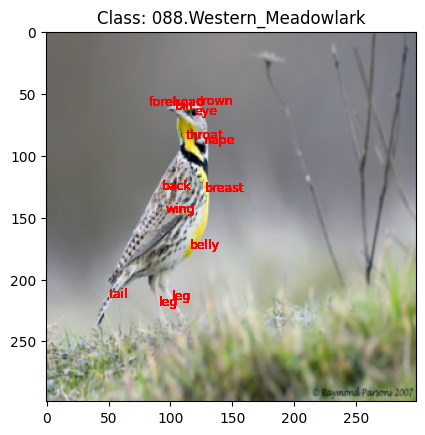

In [8]:
# Genrate the dataset
import matplotlib.pyplot as plt

picturer_idx = 2492

#picturer_idx = 2454 #Gadwell

config_dict = {'CUB_dir':r'data/CUB_200_2011','split_file':r'data\train_test_val.pkl','use_majority_voting':False,'min_class_count':10,'return_visibility':False,'hard_concept':False}
consept_names = pd.read_csv(os.path.join(config_dict['CUB_dir'],"atributes.txt"), sep=" ", header=None)[1].values
class_names = pd.read_csv(os.path.join(config_dict['CUB_dir'],"classes.txt"), sep=" ", header=None)[1].values
transform = "Resize" # "CenterCrop" or "Resize" or "RandomResized"
dataset = transform_dataset('test',config_dict,transform)


#picturer_idx = np.random.randint(0, len(dataset))
X, C, Y,coordinates = dataset.__getitem__(picturer_idx)



# Show the image and the coordinates of the concepts
plt.imshow(X.permute(1, 2, 0))
plt.title(f"Class: {class_names[torch.argmax(Y)]}")
for i in range(len(coordinates)):
    if len(coordinates[i]) > 0:

        for x,y in coordinates[i]:
            #plt.plot(x,y,'ro')
            name=consept_names[i].split("_")[1]
            if name == "forehead":
                ofset = -30

            elif name == "eye":
                ofset = 0
            else:
                ofset = 0
            
            plt.text(x+ofset,y,name,fontsize=9,color='red')
    #plt.axis('off')
            
plt.size=(50,50)
plt.show()


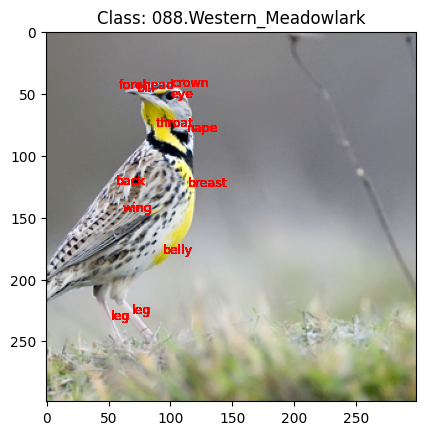

In [9]:


#picturer_idx = 2454 #Gadwell


consept_names = pd.read_csv(os.path.join(config_dict['CUB_dir'],"atributes.txt"), sep=" ", header=None)[1].values
class_names = pd.read_csv(os.path.join(config_dict['CUB_dir'],"classes.txt"), sep=" ", header=None)[1].values
transform = "CenterCrop" # "CenterCrop" or "Resize" or "RandomResized"
dataset = transform_dataset('test',config_dict,transform)


#picturer_idx = np.random.randint(0, len(dataset))
X, C, Y,coordinates = dataset.__getitem__(picturer_idx)



# Show the image and the coordinates of the concepts
plt.imshow(X.permute(1, 2, 0))
plt.title(f"Class: {class_names[torch.argmax(Y)]}")
for i in range(len(coordinates)):
    if len(coordinates[i]) > 0:

        for x,y in coordinates[i]:
            #plt.plot(x,y,'ro')
            name=consept_names[i].split("_")[1]
            if name == "forehead":
                ofset = -30

            elif name == "eye":
                ofset = 0
            else:
                ofset = 0
            
            plt.text(x+ofset,y,name,fontsize=9,color='red')
    #plt.axis('off')
            
plt.size=(50,50)
plt.show()

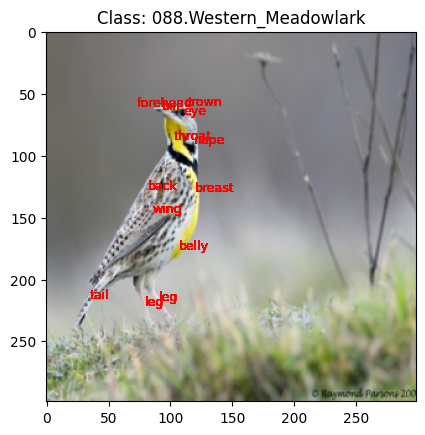

In [10]:

consept_names = pd.read_csv(os.path.join(config_dict['CUB_dir'],"atributes.txt"), sep=" ", header=None)[1].values
class_names = pd.read_csv(os.path.join(config_dict['CUB_dir'],"classes.txt"), sep=" ", header=None)[1].values
transform = "RandomResized" # "CenterCrop" or "Resize" or "RandomResized"
dataset = transform_dataset('test',config_dict,transform)


#picturer_idx = np.random.randint(0, len(dataset))
X, C, Y,coordinates = dataset.__getitem__(picturer_idx)



# Show the image and the coordinates of the concepts
plt.imshow(X.permute(1, 2, 0))
plt.title(f"Class: {class_names[torch.argmax(Y)]}")
for i in range(len(coordinates)):
    if len(coordinates[i]) > 0:

        for x,y in coordinates[i]:
            #plt.plot(x,y,'ro')
            name=consept_names[i].split("_")[1]
            if name == "forehead":
                ofset = -30

            elif name == "eye":
                ofset = 0
            else:
                ofset = 0
            
            plt.text(x+ofset,y,name,fontsize=9,color='red')
    #plt.axis('off')
            
plt.size=(50,50)
plt.show()